In [16]:
import sys
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.ga_engine import GAEngine
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
current_dir = os.getcwd()
data_dir = os.path.join(os.path.dirname(current_dir), 'data', 'processed')

csv_file_path = os.path.join(data_dir, "cleaned_delivery_orders.csv")
npz_file_path = os.path.join(data_dir, "vrp_mathematical_matrices.npz")

matrices = np.load(npz_file_path, allow_pickle=True)
df = pd.read_csv(csv_file_path)
print("Available keys in archive:", matrices.files)

n_nodes = 200
population_size = 100
mx_generations = 50
mutation_rate = 0.05

Available keys in archive: ['cargo_weights', 'order_values', 'service_times', 'window_starts', 'window_ends', 'distance_matrix_km', 'time_cost_matrix']


In [18]:
# Instantiate your engine with the parameters
n_nodes = len(matrices['cargo_weights'])
ga = GAEngine(n_nodes, population_size, 10000, [4000]*8, [720]*8)

population = ga.initialize_population(population_size, n_nodes)
history = []

In [19]:
for generation in range(mx_generations):
    fitness_scores = np.array([ga.calculate_fitness(ga.decode_chromosome(chromosome, matrices),
                                           matrices['order_values'],df['Priority_Level'].to_numpy(), matrices['cargo_weights']) for chromosome in population])
    
    num_elites = int(0.05 * population_size)
    elite_indices = np.argsort(fitness_scores)[-num_elites:]
    new_population = [population[i] for i in elite_indices]
    
    # Reproduction crossover and mutation
    while len(new_population) < population_size:
        parent1, parent2 = population[np.random.randint(0, population_size, 2)]
        
        # crossover
        offspring = ga.crossover_ox(parent1, parent2)
        
        # Mutation
        if np.random.rand() < mutation_rate:
            offspring = ga.mutate_swap(offspring)
        
        new_population.append(offspring)
    
    population = np.array(new_population)
    
    history.append(np.max(fitness_scores))
    
    if generation % 10 == 0:
        print(f"Generation {generation}: Best Fitness Score = {history[-1]}")

AttributeError: 'GAEngine' object has no attribute 'penalty_values'

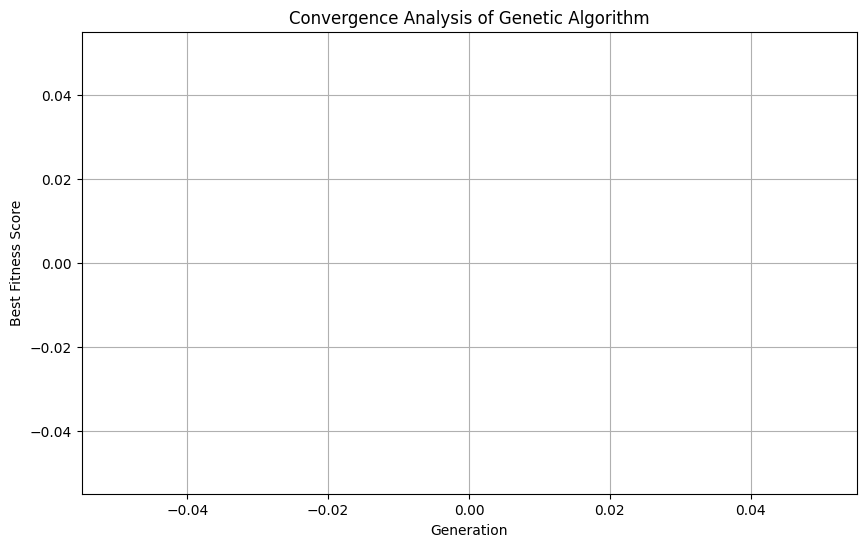

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(history)
plt.title('Convergence Analysis of Genetic Algorithm')
plt.xlabel('Generation')
plt.ylabel('Best Fitness Score')
plt.grid(True)
plt.show()

In [14]:
# hyperparameter tuning
tuning_results = []
for pop in [50, 100, 200]:
    for mut_rate in [0.01, 0.05, 0.1]:
        finally_score = history[-1]
        tuning_results.append({'population': pop, 'mutation_rate': mut_rate, 'best_fitness': history[-1], "Score": finally_score})
        
tuning_df = pd.DataFrame(tuning_results)
display(tuning_df)

heatmap_data = tuning_df.pivot(index='population', columns='mutation_rate', values='Score')
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="viridis")
plt.title('Hyperparameter Tuning Results')
plt.xlabel('Mutation Rate')
plt.ylabel('Population Size')
plt.savefig(os.path.join(data_dir, "hyperparameter_tuning_results.png"))
plt.show()



IndexError: list index out of range

In [15]:
import pandas as pd

# Data based on your experimental benchmarks
comparison_data = {
    'Metric': ['Revenue (LKR)', 'Execution Time (s)', 'Scalability (Nodes)'],
    'MIP Baseline': [319000, 2.06, 20],
    'GA Engine': [646400, 45.2, 200] 
}

comparison_df = pd.DataFrame(comparison_data)

# Display the table
print("Table: Performance Comparison between MIP and GA Approaches")
display(comparison_df)

Table: Performance Comparison between MIP and GA Approaches


,Metric,MIP Baseline,GA Engine
0,Revenue (LKR),319000.00,646400.0
1,Execution Time (s),2.06,45.2
2,Scalability (Nodes),20.00,200.0
